In [7]:
# !/usr/bin/env python
import glob
from subprocess import run

import numpy as np
import scipy.stats as stats
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from transit_time_dependence_plots import (extract_json, extract_json_tts_filter, extract_json_min_tts_filter, extract_json_tts_chi2_filter,plot_single_transit_time_histogram,
                                           prod_id_to_icm_id,extract_channel,extract_fit_params)

from refit_bad_tt_fits import merge_bins_reduceat
from transit_time_fit_functions import gaussian

from mdom_transit_time_table import get_device_list

import json

from pathlib import Path
home = str(Path.home())

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
plt.rcParams.update({'font.size': 10})


# colorsCustom = ['#8dd3c7','#bebada','#fb8072','#80b1d3','#fdb462','#b3de69','#fccde5','#d9d9d9','#bc80bd','#ccebc5','#ffed6f','#1f78b4','#33a02c','#e31a1c','#a6cee3','#b2df8a','#fb9a99','#fdbf6f','#ff7f00','#cab2d6','#ffff99','#6a3d9a','#b15928','#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e','#e6ab02','#a6761d','#666666','#1f78b4']
colorsCustom = ["#4477AA", "#EE6677", "#228833", "#CCBB44", "#66CCEE", "#AA3377", "#BBBBBB", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#000075", "#F032E6", "#42D4F4", "#FABED4", "#469990", "#DCBEFF", "#9A6324", "#FFFAC8", "#800000", "#AAFFC3", "#808000", "#FFD8B1", "#911EB4", "#3CB44B", "#E6194B", "#8B8682"]


In [8]:

from mdom_transit_time_constants import C_msu, C_desy
from transit_time_file_paths import (geometry_files,mdom_tt_dir,
                                     run_picks_json,refit_json,
                                     empty_meas_json,transit_time_file)

In [12]:
mdoms_88 = get_device_list("88","mDOM",geometry_files)

In [37]:
len(mdoms_88)

59

In [13]:
mdoms_88

['mDOM_D062',
 'mDOM_D050',
 'mDOM_D118',
 'mDOM_D012',
 'mDOM_D068',
 'mDOM_D074',
 'mDOM_D004',
 'mDOM_D043',
 'mDOM_D075',
 'mDOM_D034',
 'mDOM_D032',
 'mDOM_D076',
 'mDOM_D120',
 'mDOM_D174',
 'mDOM_D082',
 'mDOM_D017',
 'mDOM_D087',
 'mDOM_D090',
 'mDOM_D061',
 'mDOM_D021',
 'mDOM_D059',
 'mDOM_D063',
 'mDOM_D013',
 'mDOM_D125',
 'mDOM_D217',
 'mDOM_D079',
 'mDOM_D029',
 'mDOM_D024',
 'mDOM_D117',
 'mDOM_D141',
 'mDOM_D023',
 'mDOM_D104',
 'mDOM_D109',
 'mDOM_D055',
 'mDOM_D044',
 'mDOM_D056',
 'mDOM_D041',
 'mDOM_D226',
 'mDOM_D123',
 'mDOM_D058',
 'mDOM_D099',
 'mDOM_D110',
 'mDOM_D135',
 'mDOM_D127',
 'mDOM_D077',
 'mDOM_D052',
 'mDOM_D093',
 'mDOM_D071',
 'mDOM_D139',
 'mDOM_D019',
 'mDOM_D001',
 'mDOM_D130',
 'mDOM_D105',
 'mDOM_D102',
 'mDOM_D086',
 'mDOM_D134',
 'mDOM_D039',
 'mDOM_D003',
 'mDOM_D165']

In [26]:
def extract_json_site(transit_time_file,site_str,obj_key,filter_non_zero) -> list:
    '''
    Reads the json file with the list of DOMs and transit time measurements and returns a list of transit times
    and other data values
    for chi2, object key : "chi2"
    for transit time, object key:"mu"

    '''
    data_values = []
    tt_less_23 = []
    unique_mDOMs = []    
    with open(transit_time_file, 'r') as f:
        data = json.load(f)
        for mdom, tt_data in data.items():
            print(mdom)
            print(mdom in mdoms_88)
            if mdom in mdoms_88:
                if site_str in mdom:
                    for ichannel in tt_data["transit_times"]:
                        for itt in tt_data["transit_times"][ichannel]:
                            if len(itt) > 0 and itt["sigma"] > 4:
                            # if itt["mu"] < 23:
                                tt_less_23.append(f"{mdom}_{ichannel}_{itt['run_number']}")
                                unique_mDOMs.append(f"{mdom}")
                            if len(itt) > 0:
                                if filter_non_zero:
                                    if abs(itt["mu"]) > 0:
                                        data_values.append(itt[obj_key])
                                else:
                                    data_values.append(itt[obj_key])
    # print(tt_less_23)
    return data_values

In [57]:
transit_times_single_gaussian_file = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mdom_transit_time_gaussian_refit.json"
transit_times_single_file = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mdom_transit_time_single_pick.json"

In [31]:
tt_88 = extract_json_site(transit_times_single_gaussian_file,site_str="_D",obj_key="mu",filter_non_zero=False)

mDOM_M061
False
mDOM_M030
False
mDOM_M170
False
mDOM_M183
False
mDOM_M092
False
mDOM_M115
False
mDOM_M055
False
mDOM_M045
False
mDOM_M105
False
mDOM_M014
False
mDOM_M154
False
mDOM_M082
False
mDOM_M193
False
mDOM_M202
False
mDOM_M160
False
mDOM_M071
False
mDOM_M051
False
mDOM_M140
False
mDOM_M065
False
mDOM_M125
False
mDOM_M096
False
mDOM_M197
False
mDOM_M086
False
mDOM_M075
False
mDOM_M164
False
mDOM_M024
False
mDOM_M010
False
mDOM_M150
False
mDOM_M101
False
mDOM_M110
False
mDOM_M050
False
mDOM_M001
False
mDOM_M035
False
mDOM_M175
False
mDOM_M064
False
mDOM_M124
False
mDOM_M186
False
mDOM_M196
False
mDOM_M134
False
mDOM_M074
False
mDOM_M165
False
mDOM_M025
False
mDOM_M011
False
mDOM_M151
False
mDOM_M040
False
mDOM_M100
False
mDOM_M060
False
mDOM_M120
False
mDOM_M171
False
mDOM_M182
False
mDOM_M093
False
mDOM_M145
False
mDOM_M005
False
mDOM_M114
False
mDOM_M054
False
mDOM_M044
False
mDOM_M155
False
mDOM_M083
False
mDOM_M203
False
mDOM_M161
False
mDOM_M021
False
mDOM_M130
False
mDOM_M18

In [32]:
tt_88

[30.53150126879037,
 31.376324565312466,
 29.471118484892976,
 30.42557111139672,
 30.973936101096612,
 31.632152050579066,
 30.393488756804203,
 30.151373780521517,
 30.48252467406671,
 30.19206367201933,
 31.705438662903283,
 30.540607938206364,
 30.829887965805398,
 30.046782120253006,
 31.056532865697115,
 30.42522950719887,
 30.83675198125823,
 30.45254484849699,
 29.268985927589334,
 30.354003119011594,
 29.99663354201531,
 30.756986322623355,
 30.32410822970573,
 31.54203394484297,
 31.134647527043718,
 32.32923393036391,
 30.88502274261885,
 30.331143930976324,
 31.78643485907766,
 31.773143909178977,
 30.614780493096404,
 30.806403383870816,
 30.560448984714036,
 31.027472689304524,
 31.718348265033505,
 31.29120942127144,
 31.245248055485412,
 30.847095700170748,
 32.220846217307894,
 31.469994568778624,
 32.38054857071213,
 32.01864708480101,
 31.651056333508023,
 32.006190250246746,
 31.76404975539709,
 32.76579030518562,
 32.33525118873116,
 32.501251789659406,
 31.2046695

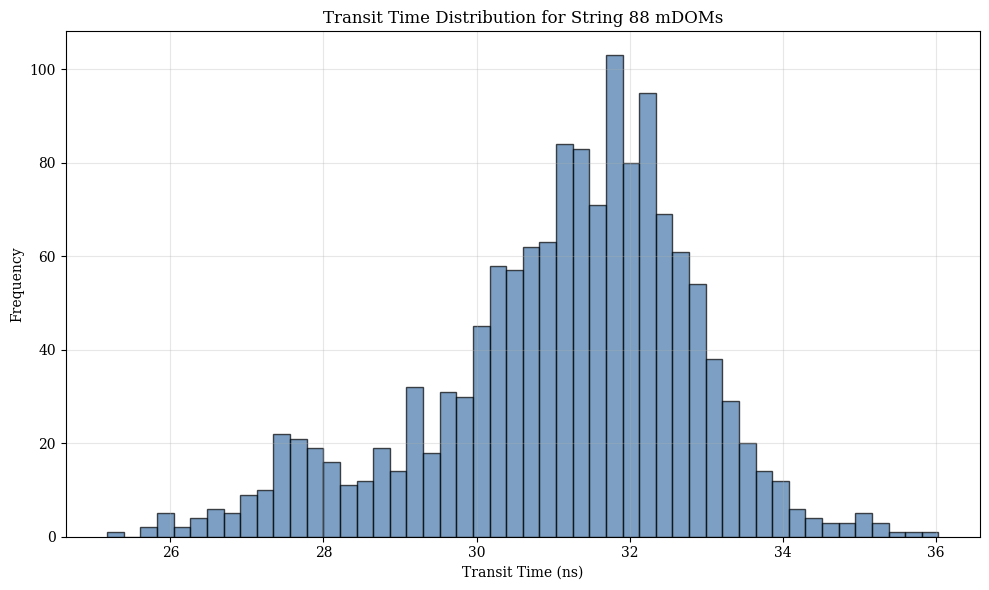

In [33]:
def plot_transit_time_histogram(tt_data, bins=50, figsize=(10, 6)):
    '''
    Plot histogram of transit time data
    
    Parameters:
    tt_data (list): List of transit time values
    bins (int): Number of bins for histogram
    figsize (tuple): Figure size (width, height)
    '''
    plt.figure(figsize=figsize)
    plt.hist(tt_data, bins=bins, color=colorsCustom[0], edgecolor='black', alpha=0.7)
    plt.xlabel('Transit Time (ns)')
    plt.ylabel('Frequency')
    plt.title('Transit Time Distribution for String 88 mDOMs')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Call the function to plot tt_88
plot_transit_time_histogram(tt_88)

In [35]:
def plot_color_plot():
    import numpy as np
    from scipy.stats import norm
    from scipy.stats import uniform
    from scipy.stats import poisson
    import matplotlib.pyplot as plt
    import scipy.integrate as s
    import scipy.stats as st

    # This code will sample from a bivariate gaussian with
    # mean_x = 10, var_x = 2.3, mean_y = -2.0, var_y = 0.5
    # and correlation coefficient 0
    xmean = 10.0
    ymean = -2.0
    xvar = 2.3
    yvar = 0.5
    pearson_r = 0

    # calculate the covariance from the above for the covariance matrix
    covar = pearson_r*np.sqrt(xvar)*np.sqrt(yvar)
    nsample = 50000

    # first we set the array of mean values
    mean = [xmean, ymean]

    # then we set the covariance matrix. Note the 2 x 2 matrix is
    # an array of arrays.

    cov = [[xvar,covar],[covar,yvar]]
    x, y = np.random.multivariate_normal(mean, cov, nsample).T

    plt.clf()
    # save the output of the 2 d histogram.
    bins, xedges, yedges, patches = plt.hist2d(x, y,bins=30)
    # assign the colorbar to the "cbar" variable
    cbar = plt.colorbar()
    cbar.set_label('histogram height', rotation=270,labelpad=10) #The labelpad sets the offset of the colorbar label
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


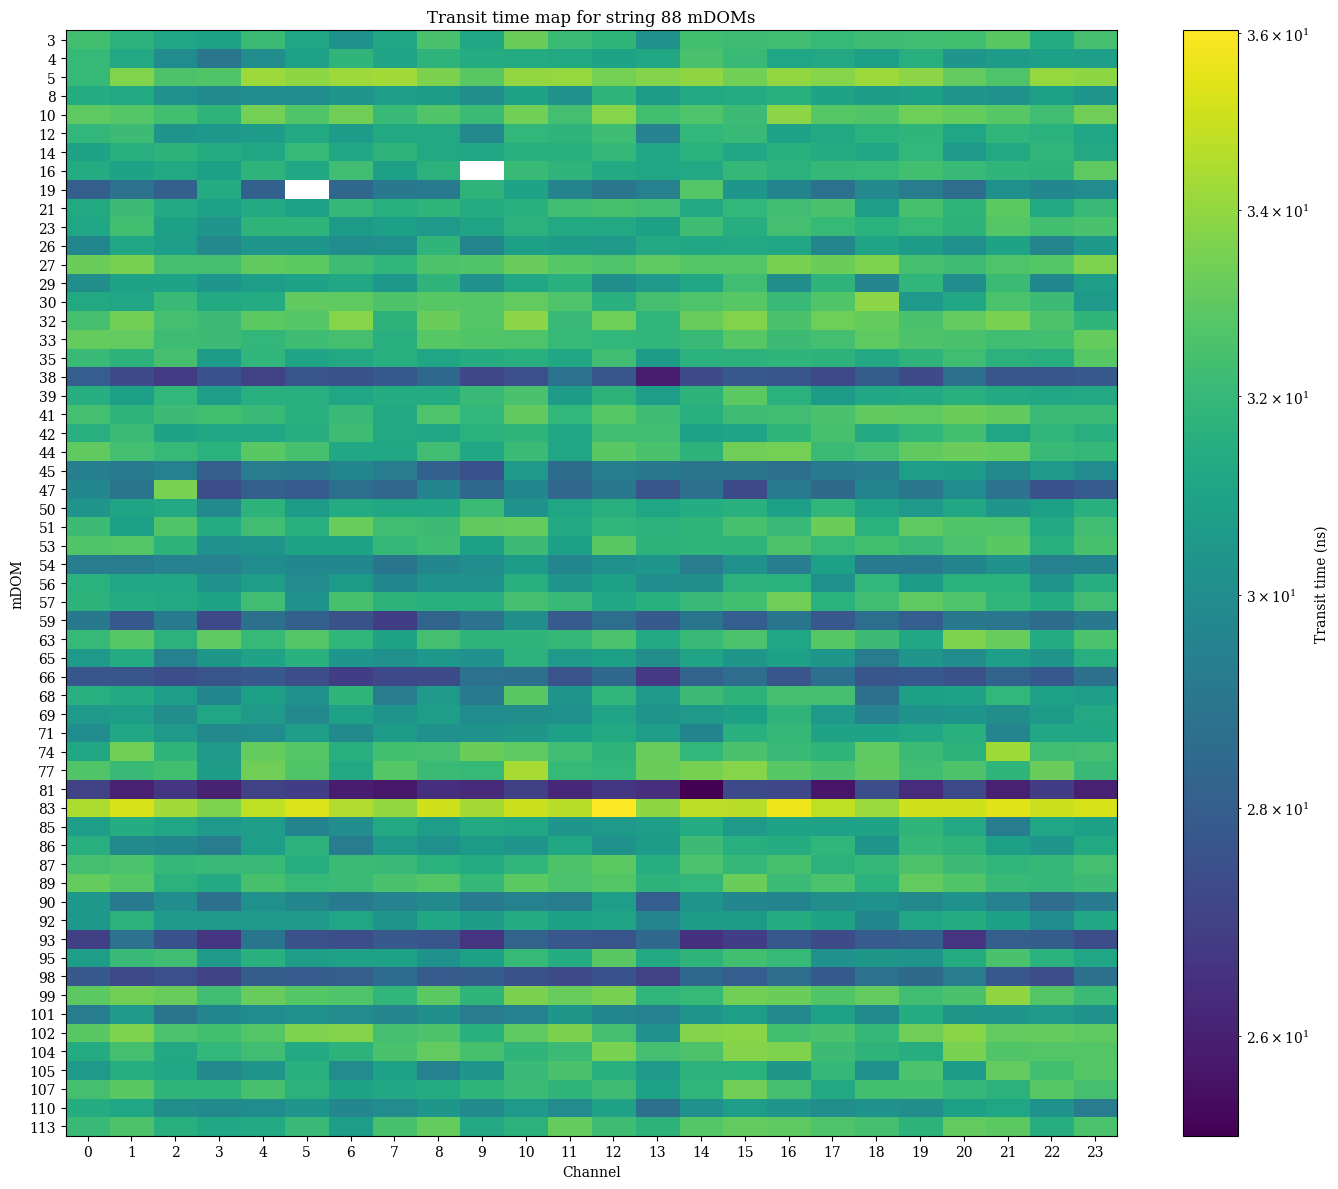

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


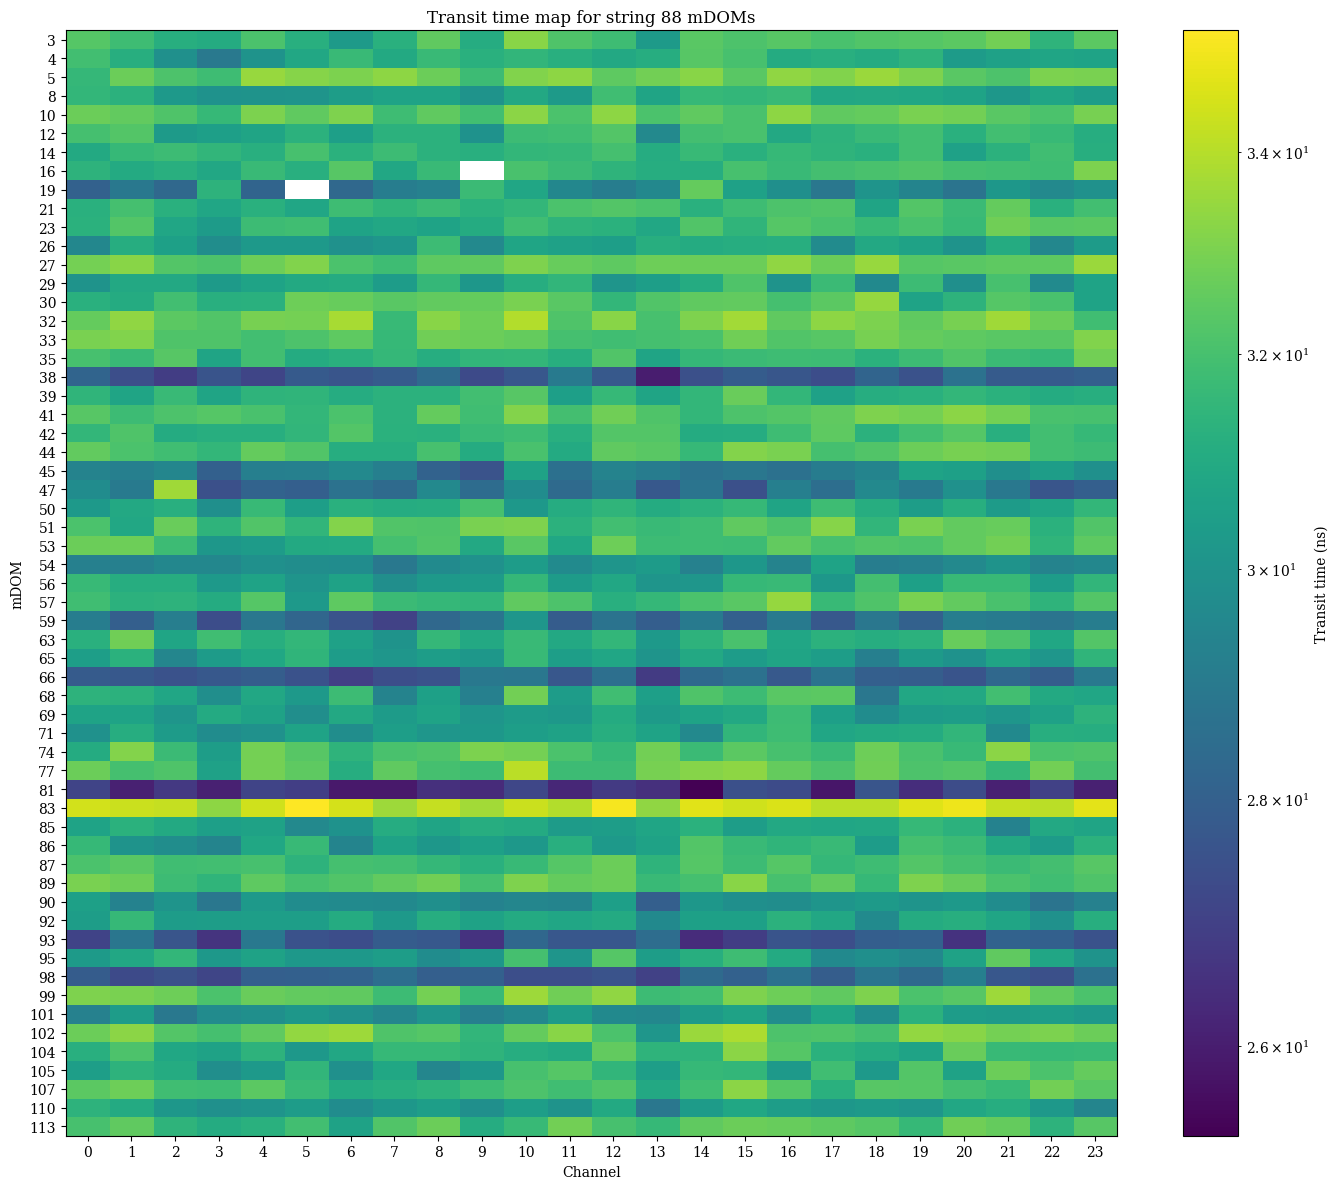

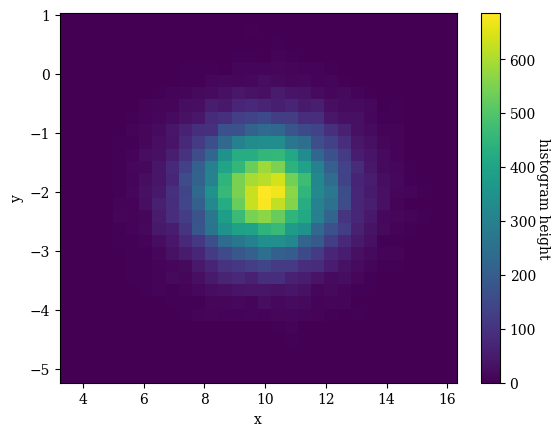

In [36]:
plot_color_plot()

In [46]:
from geometry_util import prod_id_to_icm_id,get_string_position_from_icm_id

In [62]:
from collections import defaultdict
import matplotlib

def plot_2d_histogram_from_transit_times(transit_time_file):

    with open(transit_time_file, "r") as f:
        data = json.load(f)

    # Collect transit times per (mdom, channel)
    cell_values = defaultdict(list)
    channels = set()

    for mdom, tt_data in data.items():
        if mdom in mdoms_88 and "_D" in mdom:
            icm_id = prod_id_to_icm_id(mdom,geometry_files)
            pos,string = get_string_position_from_icm_id(icm_id,geometry_files)
            # print(f"mDOM: {mdom}, ICM ID: {icm_id}, String Position: {string_pos}")
            for channel, measurements in tt_data["transit_times"].items():
                channels.add(int(channel.split("_")[1]))  # Extract channel number
                for itt in measurements:
                    if len(itt) > 0 and "mu" in itt:
                        # cell_values[(mdom, int(channel.split("_")[1]))].append(itt["mu"])
                        cell_values[(pos, int(channel.split("_")[1]))].append(itt["mu"])

    # print(cell_values)

    # Build ordered axes
    mdom_order = [mdom for mdom in mdoms_88 if mdom in {k[0] for k in cell_values.keys()}]
    mdom_pos_order = [pos for pos in {k[0] for k in cell_values.keys()}]
    channel_order = sorted(channels)
    mdom_pos_order.sort(reverse=True)  # Reverse to have mDOM 1 at the bottom
    print(channel_order)

    # Fill matrix with mean transit time per mDOM/channel
    Z = np.full((len(mdom_pos_order), len(channel_order)), np.nan)
    for i, pos in enumerate(mdom_pos_order):
        for j, ch in enumerate(channel_order):
            vals = cell_values.get((pos, ch), [])
            if vals:
                Z[i, j] = np.mean(vals)

    # Plot discrete 2D histogram / heatmap
    plt.figure(figsize=(14, 12))
    im = plt.imshow(
        Z,
        aspect="auto",
        origin="lower",
        interpolation="none",
        cmap="viridis",
        norm=matplotlib.colors.LogNorm(vmin=np.nanmin(Z), vmax=np.nanmax(Z))
    )

    plt.colorbar(im, label="Transit time (ns)")
    plt.xticks(np.arange(len(channel_order)), channel_order)
    plt.yticks(np.arange(len(mdom_pos_order)), mdom_pos_order)
    plt.xlabel("Channel")
    plt.ylabel("mDOM OM position")
    plt.title("Transit time map for string 88 mDOMs")
    plt.tight_layout()
    plt.show()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


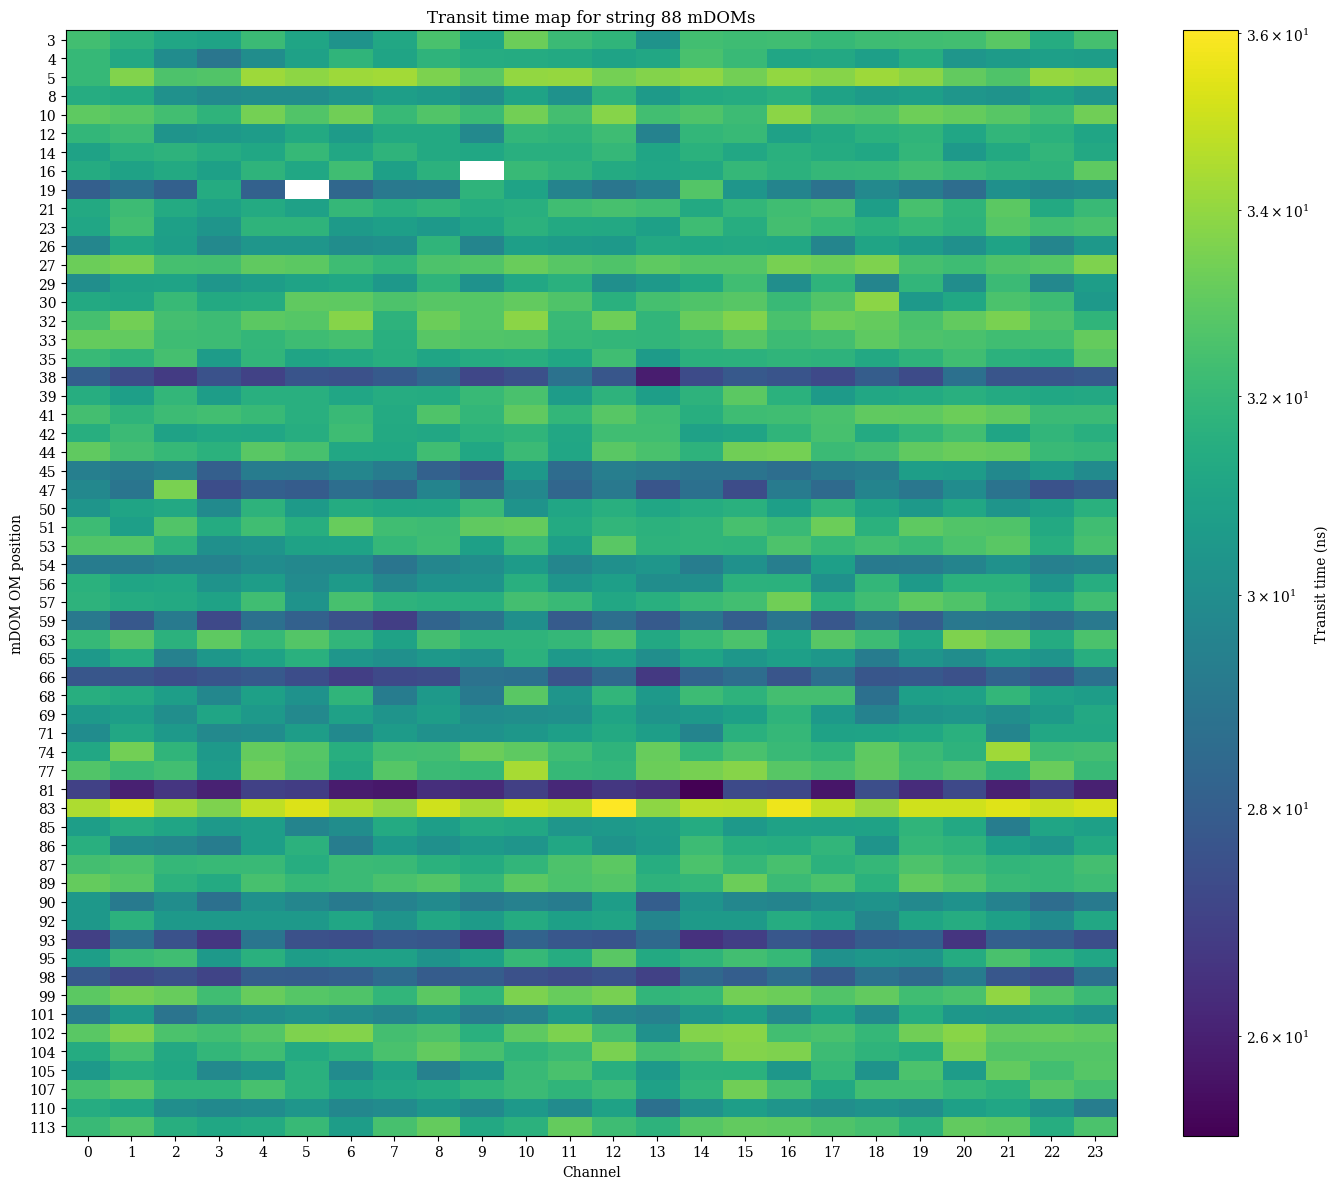

In [63]:
plot_2d_histogram_from_transit_times(transit_times_single_gaussian_file)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


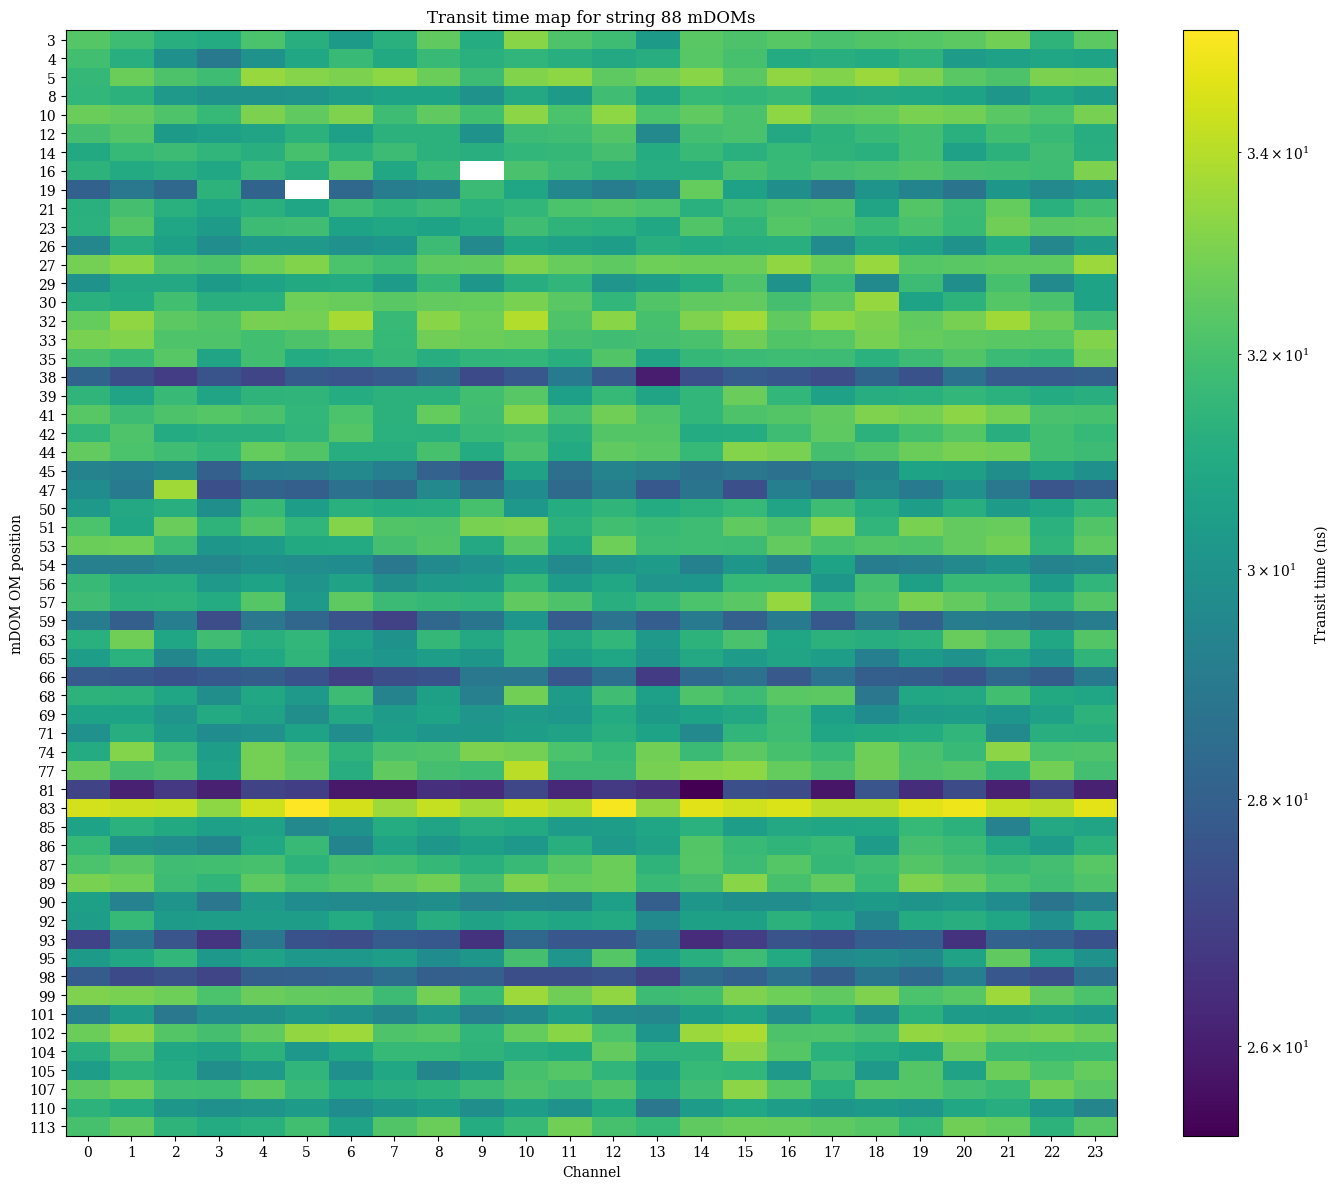

In [64]:
plot_2d_histogram_from_transit_times(transit_times_single_file)
